## After the Erebus fit is done running, this notebook loads the output and puts it into the RW data challenge object format

In [9]:
path_to_joint_fit_results = "Erebus_Output/GJ3929b_joint_fit.h5"
path_to_full_chain = "Erebus_Output/full_chain.npy"

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import rocky_worlds_data_challenge as rw
from erebus.joint_fit_results import JointFitResults
from erebus.plotting import plot_joint_fit
import pandas as pd
import h5py

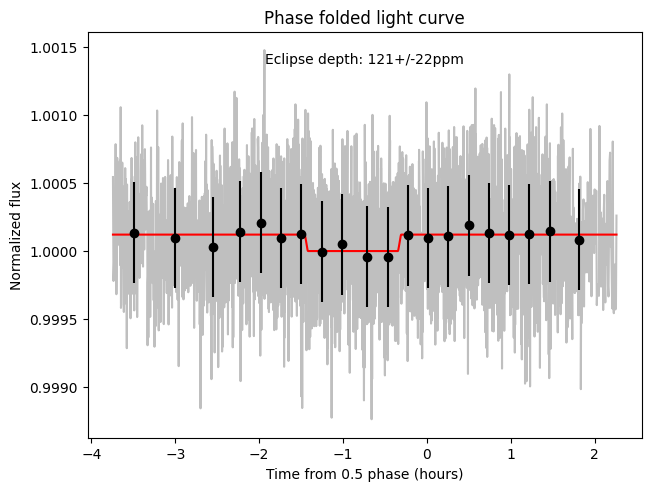

In [11]:
# Load time, detrended flux, model flux, systematic model from Erebus joint fit file
res = JointFitResults.load(path_to_joint_fit_results)
plot_joint_fit(res, show=True)

x = np.array([res.time_per_visit[i] / 24.0 + res.predicted_t_secs[f'{i}'] for i in range(4)]).flatten()
y = res.detrended_flux_per_visit.flatten()
y_model = res.model_flux_per_visit.flatten()
sys_model = res.systematic_per_visit.flatten()
inds = np.isnan(x)
x = x[~inds]
y = y[~inds]
y_model = y_model[~inds]
sys_model = sys_model[~inds]

times = x
detrended_flux = y

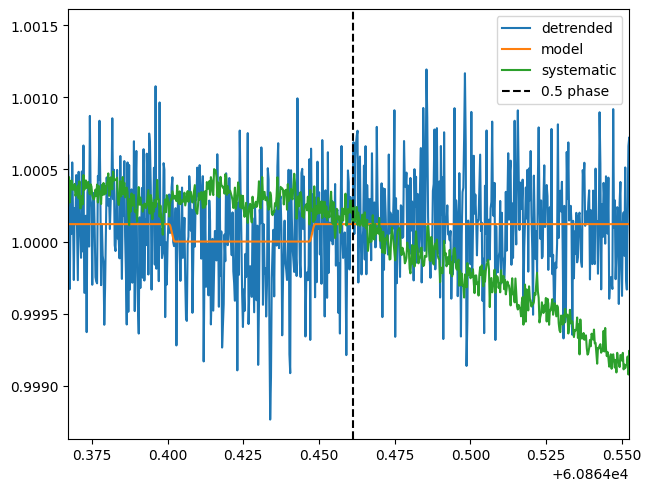

In [12]:
# Check for proper arrays, sanity check visit 1
plt.plot(times, detrended_flux, label='detrended')
plt.plot(times, y_model, label='model')
plt.plot(times, sys_model, label='systematic')
plt.xlim([times[0], times[700]])

plt.axvline(res.predicted_t_secs['0'], color='black', linestyle='--', label='0.5 phase')
plt.legend()

In [13]:
# astrophysical parameters
chain = np.load(path_to_full_chain)
param_names = ["fp", "rp_rstar", "a_rstar", "inc", "t_sec"]
posteriors = [chain[-1000:,:,i].flatten() for i in range(len(param_names))]

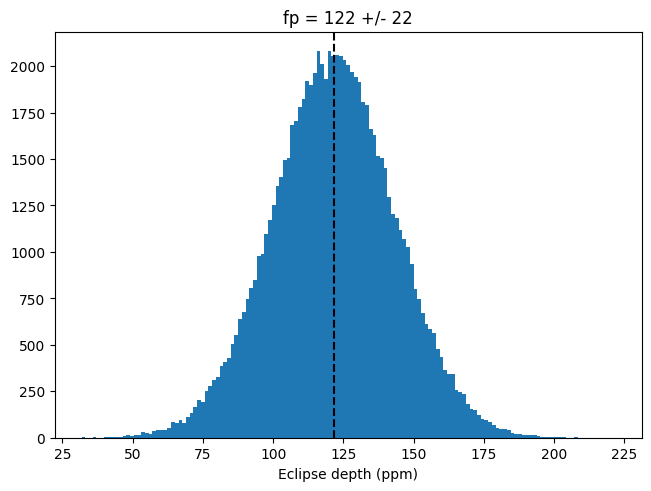

In [14]:
fp = posteriors[0]*1e6
plt.hist(fp, bins="fd")
plt.title(f"fp = {np.median(fp):.0f} +/- {np.std(fp):.0f}")
plt.axvline(np.median(fp), color='black', linestyle='--')
plt.xlabel("Eclipse depth (ppm)")
plt.show()

In [15]:
rw_posterior = rw.Posterior(
	samples=[posteriors[0]*1e6, posteriors[1], posteriors[2], posteriors[3], posteriors[4] + res.predicted_t_secs['0']],
	parameter_keys = ['depth_ecl', "rp_rstar", "a_rstar", "inc", 't_ecl']
)
rw_posterior.validate()

photometry_GJ_3929_b = rw.Photometry(
    time=res.time,
    raw_flux=res.raw_flux,
    raw_flux_err=np.ones_like(res.raw_flux) * res.results["y_err"].nominal_value,
    astro_model=y_model,
    noise_model=sys_model,
    full_model=y_model * sys_model,
)

photometry_GJ_3929_b.validate()

In [16]:
pd.DataFrame(
	data=rw_posterior.samples.T,
	columns=rw_posterior.parameter_keys
).to_csv(
	"posterior_GJ3929b.txt",
	index=False,
)

with h5py.File("lc_GJ3929b.h5", 'w') as h5_file:
	samples_group = h5_file.create_dataset(
		'posterior_samples',
		data=rw_posterior.samples
	)
	samples_group.attrs['parameter_keys'] = rw_posterior.parameter_keys

	photometry_group = h5_file.create_group('photometry')

	for field, array in vars(photometry_GJ_3929_b).items():
		photometry_group.create_dataset(field, data=array)